## Perturbation simulation

In [ ]:
import os
os._exit(00)

In [1]:
import scenicplus
print(scenicplus.__version__)

1.0.1.dev6+ge5ba6fc


## Setting up work environment

In [22]:
#supress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import sys
import os
import dill
work_dir = '/wynton/group/pollen/jding/Sara/data/scenicplus'
#work_dir = '/wynton/group/pollen/jding/Sara/data/Chimp'
tmp_dir = '/wynton/scratch/jding/'

if not os.path.exists(work_dir):
    os.makedirs(work_dir)

In [23]:
import dill
scplus_obj = dill.load(open(os.path.join(work_dir, 'scenicplus/scplus_obj.pkl'), 'rb'))

In [24]:
from scenicplus.preprocessing.filtering import apply_std_filtering_to_eRegulons
apply_std_filtering_to_eRegulons(scplus_obj)

Only keeping positive R2G
Only keep extended if not direct
Getting signatures...
Simplifying eRegulons ...


In [25]:
from scenicplus.eregulon_enrichment import score_eRegulons
region_ranking = dill.load(open(os.path.join(work_dir, 'scenicplus/region_ranking.pkl'), 'rb')) #load ranking calculated using the wrapper function
gene_ranking = dill.load(open(os.path.join(work_dir, 'scenicplus/gene_ranking.pkl'), 'rb')) #load ranking calculated using the wrapper function
score_eRegulons(scplus_obj,
                ranking = region_ranking,
                eRegulon_signatures_key = 'eRegulon_signatures_filtered',
                key_added = 'eRegulon_AUC_filtered',
                enrichment_type= 'region',
                auc_threshold = 0.05,
                normalize = False,
                n_cpu = 12)
score_eRegulons(scplus_obj,
                gene_ranking,
                eRegulon_signatures_key = 'eRegulon_signatures_filtered',
                key_added = 'eRegulon_AUC_filtered',
                enrichment_type = 'gene',
                auc_threshold = 0.05,
                normalize= False,
                n_cpu = 12)

In [26]:
from scenicplus.dimensionality_reduction import run_eRegulons_pca
run_eRegulons_pca(
        scplus_obj,
        auc_key = 'eRegulon_AUC_filtered',
        reduction_name = 'eRegulons_PCA_gene_based',
        selected_regulons = scplus_obj.uns['eRegulon_signatures_filtered']['Gene_based'],
        n_pcs = 10)

In [72]:
#load PCA from scRNA
import scanpy as sc
#ad = sc.read('/wynton/group/pollen/jding/Sara/data/scRNA/20240305_GEX_D80_rot_challenge_rPCA_DA_subset.h5ad')
ad = sc.read('/wynton/group/pollen/jding/Sara/20241011_GEX_D80_rot_challenge_rPCA_DA_subset.h5ad')
ad.obs['barcode'] = [x.split("_")[-1] for x in ad.obs_names]
ad.obs.index = ad.obs['barcode'].astype(str) +'-'+ad.obs['orig.ident'].astype(str)
ad.obs['barcode'] = [x.split('-')[0] for x in ad.obs.index]
ad.obs.index = ad.obs['barcode'].astype(str) +'-1___'+ ad.obs['orig.ident'].astype(str)
ad = ad[scplus_obj.dr_cell['eRegulons_PCA_gene_based'].index,:]
ad.obs.head()

KeyError: "Values ['TTTGACTTCCGGTTGA-1___D80_M_0-8_72H_Human', 'GTTACCTGTATTTGCC-1___D80_M_0-8_24H_Human', 'TCTCGCCCAGCAAGGC-1___D80_M_0-8_24H_Human', 'GATTGGTTCCTCCCTC-1___D80_M_0-8_72H_Human', 'ATTCGTTTCCTAAGTA-1___D80_M_0-8_CNTRL_Human', 'AGCTCATAGTTGCCTC-1___D80_M_0-8_24H_Human', 'TTTGCGGAGGCGAATA-1___D80_M_0-8_72H_Human', 'GGCCTCTGTTCTTTAG-1___D80_M_0-8_CNTRL_Human', 'CTACTTAGTTGAAGCC-1___D80_M_0-8_CNTRL_Human', 'ATGAAGTAGTCACCAG-1___D80_M_0-6_CNTRL_Human', 'GTAAGCTTCGTTACAA-1___D80_M_0-8_CNTRL_Human', 'GGTTCCCGTCAATGTG-1___D80_M_0-8_24H_Human', 'CATAGGCGTTTGGCTT-1___D80_M_0-8_24H_Human', 'GTGTGAGCAGTAGGTG-1___D80_M_0-8_72H_Human', 'GCAAGTCGTGGTTATG-1___D80_M_0-8_72H_Human', 'ACATTGCAGACCATAC-1___D80_M_0-6_72H_Human', 'ACCAGGGAGCACGTTG-1___D80_M_0-6_24H_Human', 'TAGGCTGTCCCTCAGT-1___D80_M_0-6_CNTRL_Human', 'TCGGTTCTCAATTACG-1___D80_M_0-6_24H_Human', 'TTCATCCCAACTCGCG-1___D80_M_0-8_CNTRL_Human', 'AATCATCCAGAAATGC-1___D80_M_0-8_CNTRL_Human', 'GGTAATTGTTTAAAGC-1___D80_M_0-8_24H_Human

In [111]:
ad = sc.read('/wynton/group/pollen/jding/Sara/20241011_GEX_D80_rot_challenge_rPCA_DA_subset.h5ad')
ad.obs.head()

,orig.ident,nCount_RNA,nFeature_RNA,species,percent.mt,percent.ribo,condition,unintegrated_clusters,seurat_clusters,RNA_snn_res.1,RNA_snn_res.0.4,Indiv,SorD,barcode_seurat,cluster,original_cluster,species_condition
D80_M_0-6_24H_Human_AAAGCTTGTTGGTTCT-1,D80_M_0-6_24H_Human,6001.0,2966,Human,0.433261,1.249792,24H,17,4,14,4,H21194,S,D80_M_0-6_24H_Human_AAAGCTTGTTGGTTCT-1,4,14,Human_24H
D80_M_0-6_24H_Human_AAAGGCTCACACTAAT-1,D80_M_0-6_24H_Human,7291.0,3669,Human,0.000000,5.925113,24H,6,5,3,5,H21194,S,D80_M_0-6_24H_Human_AAAGGCTCACACTAAT-1,5,3,Human_24H
D80_M_0-6_24H_Human_AACAAAGGTTTGTGGA-1,D80_M_0-6_24H_Human,4304.0,2469,Human,3.880112,5.204461,24H,6,1,3,1,H29089,S,D80_M_0-6_24H_Human_AACAAAGGTTTGTGGA-1,1,3,Human_24H
D80_M_0-6_24H_Human_AAGCTTGGTGATTTGG-1,D80_M_0-6_24H_Human,4366.0,2480,Human,0.137426,2.382043,24H,6,1,3,1,H9,S,D80_M_0-6_24H_Human_AAGCTTGGTGATTTGG-1,1,3,Human_24H
D80_M_0-6_24H_Human_AAGGATTAGGAGGTTA-1,D80_M_0-6_24H_Human,5750.0,2803,Human,0.382609,1.652174,24H,17,3,15,3,H21194,S,D80_M_0-6_24H_Human_AAGGATTAGGAGGTTA-1,3,15,Human_24H


In [27]:
#use pc1,pc2 to visualize KD simulation
import sklearn
import pandas as pd
from sklearn.decomposition import PCA

auc_key = 'eRegulon_AUC'
signature_keys = ['Gene_based', 'Region_based']
reduction_name = 'eRegulons_PCA_gene_based'
selected_regulons = scplus_obj.uns['eRegulon_signatures_filtered']['Gene_based']
n_pcs = 10

data_mat = pd.concat([pd.DataFrame(sklearn.preprocessing.StandardScaler().fit_transform(
            scplus_obj.uns[auc_key][x].T), index=scplus_obj.uns[auc_key][x].T.index.to_list(), columns=scplus_obj.uns[auc_key][x].T.columns) for x in signature_keys])
data_mat = data_mat.T.fillna(0)
reducer = PCA(n_components=n_pcs, random_state=555)
embedding = reducer.fit_transform(data_mat)
data_names = data_mat.T.columns.tolist()

dr = pd.DataFrame(
        embedding,
        index=data_names,
        columns=[f'PC_{i}' for i in range(n_pcs)])[['PC_1', 'PC_2']]
if not hasattr(scplus_obj, 'dr_cell'):
    scplus_obj.dr_cell = {}
scplus_obj.dr_cell[reduction_name] = dr

In [108]:
gene_loadings = reducer.components_.T  
top_genes_pc0 = pd.DataFrame(data=gene_loadings[:, 0], index=data_mat.T.index, columns=["PC0_loading"]).sort_values("PC0_loading", ascending=False).head(15)
top_genes_pc1 = pd.DataFrame(data=gene_loadings[:, 1], index=data_mat.T.index, columns=["PC1_loading"]).sort_values("PC1_loading", ascending=False).head(15)
top_genes_pc2 = pd.DataFrame(data=gene_loadings[:, 2], index=data_mat.T.index, columns=["PC2_loading"]).sort_values("PC2_loading", ascending=False).head(15)
print(top_genes_pc0)
print(top_genes_pc1)
print(top_genes_pc2)

                           PC0_loading
DRAP1_extended_+_-_(162g)     0.286425
NR3C1_-_-_(11g)               0.285547
DRAP1_+_-_(153g)              0.282074
MAZ_+_-_(224g)                0.243132
MAZ_extended_+_-_(238g)       0.242511
NR3C1_extended_-_-_(11g)      0.238427
MAZ_extended_+_+_(224g)       0.226466
MAZ_+_+_(222g)                0.221302
NR4A1_extended_+_+_(67g)      0.143174
ZGPAT_+_+_(13r)               0.116281
EN1_+_+_(42g)                 0.101970
MAZ_+_+_(517r)                0.084174
MAZ_extended_+_+_(607r)       0.077007
ZNF543_extended_+_+_(12r)     0.075397
FOXJ1_extended_+_+_(21r)      0.074280
                            PC1_loading
CREB5_extended_+_+_(91g)       0.284827
CREB5_+_+_(99g)                0.247405
BACH2_+_+_(454g)               0.208554
BACH2_extended_+_+_(527g)      0.194035
SREBF2_extended_+_-_(512g)     0.159937
DLX4_extended_+_+_(10g)        0.157871
SOX12_extended_+_-_(9r)        0.132696
TCF12_+_-_(320g)               0.126800
TCF12_extended_+

In [67]:
#add pca values from scRNA to scplus object
#use PC1 and PC2
#scplus_obj.dr_cell['X_pca'] = scplus_obj.dr_cell['eRegulons_PCA_gene_based']
#scplus_obj.dr_cell['X_pca']['PC_1'] = pd.DataFrame(ad.obsm['X_pca'], index = ad.obs_names)[0]
#scplus_obj.dr_cell['X_pca']['PC_2'] = pd.DataFrame(ad.obsm['X_pca'], index = ad.obs_names)[1]
#del scplus_obj.dr_cell['X_pca']['PC_0']

## Plotting perturbation effect on an embedding


In [28]:
from pycisTopic.diff_features import find_highly_variable_features
hvg = find_highly_variable_features(scplus_obj.to_df('EXP')[list(set(scplus_obj.uns['eRegulon_metadata_filtered']['Gene']))].T, n_top_features = 500, plot = False)

2024-10-24 08:04:50,402 cisTopic     INFO     Calculating mean
2024-10-24 08:04:50,404 cisTopic     INFO     Calculating variance
2024-10-24 08:04:50,477 cisTopic     INFO     Done!


<Figure size 640x480 with 0 Axes>

/wynton/home/pollenlab/jding/miniconda3/envs/scenicplus-new/lib/python3.8/site-packages/loompy/bus_file.py:68: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def twobit_to_dna(twobit: int, size: int) -> str:
/wynton/home/pollenlab/jding/miniconda3/envs/scenicplus-new/lib/python3.8/site-packages/loompy/bus_file.py:85: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  

2024-10-21 08:20:59,948 perturbation INFO     Caclulating perturbation matrix for: {'PBX1': 0} over 5 iterations.


100%|█████████████████████████████████████████| 500/500 [02:35<00:00,  3.22it/s]


2024-10-21 08:23:48,213 perturbation INFO     Generating ranking based on perturbed matrix.
2024-10-21 08:23:52,770 perturbation INFO     Scoring eRegulons.
2024-10-21 08:23:57,953 perturbation INFO     Projecting perturbation effect in embedding: eRegulons_PCA_gene_based
2024-10-21 08:23:58,427 perturbation INFO     Calculating grid of arrows
2024-10-21 08:23:58,515 perturbation INFO     Plotting


/wynton/home/pollenlab/jding/scenicplus/src/scenicplus/simulation.py:292: RuntimeWarning: invalid value encountered in divide
  unitary_vectors /= np.linalg.norm(unitary_vectors, ord=2, axis=0)  # divide by L2


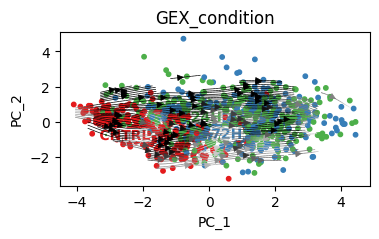

2024-10-21 08:24:03,795 perturbation INFO     Caclulating perturbation matrix for: {'POU3F2': 0} over 5 iterations.


100%|█████████████████████████████████████████| 500/500 [02:34<00:00,  3.23it/s]


2024-10-21 08:26:54,295 perturbation INFO     Generating ranking based on perturbed matrix.
2024-10-21 08:26:58,979 perturbation INFO     Scoring eRegulons.
2024-10-21 08:27:04,055 perturbation INFO     Projecting perturbation effect in embedding: eRegulons_PCA_gene_based
2024-10-21 08:27:04,365 perturbation INFO     Calculating grid of arrows
2024-10-21 08:27:04,454 perturbation INFO     Plotting


/wynton/home/pollenlab/jding/scenicplus/src/scenicplus/simulation.py:292: RuntimeWarning: invalid value encountered in divide
  unitary_vectors /= np.linalg.norm(unitary_vectors, ord=2, axis=0)  # divide by L2


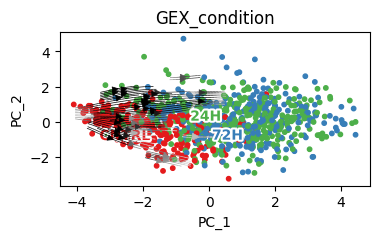

2024-10-21 08:27:09,422 perturbation INFO     Caclulating perturbation matrix for: {'BACH2': 0} over 5 iterations.


100%|█████████████████████████████████████████| 500/500 [02:31<00:00,  3.30it/s]


2024-10-21 08:29:57,480 perturbation INFO     Generating ranking based on perturbed matrix.
2024-10-21 08:30:02,078 perturbation INFO     Scoring eRegulons.
2024-10-21 08:30:07,329 perturbation INFO     Projecting perturbation effect in embedding: eRegulons_PCA_gene_based
2024-10-21 08:30:07,624 perturbation INFO     Calculating grid of arrows
2024-10-21 08:30:07,712 perturbation INFO     Plotting


/wynton/home/pollenlab/jding/scenicplus/src/scenicplus/simulation.py:292: RuntimeWarning: invalid value encountered in divide
  unitary_vectors /= np.linalg.norm(unitary_vectors, ord=2, axis=0)  # divide by L2


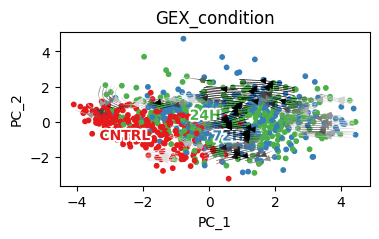

2024-10-21 08:30:12,923 perturbation INFO     Caclulating perturbation matrix for: {'CREB5': 0} over 5 iterations.


100%|█████████████████████████████████████████| 500/500 [02:37<00:00,  3.18it/s]


2024-10-21 08:32:57,059 perturbation INFO     Generating ranking based on perturbed matrix.
2024-10-21 08:33:01,865 perturbation INFO     Scoring eRegulons.
2024-10-21 08:33:07,024 perturbation INFO     Projecting perturbation effect in embedding: eRegulons_PCA_gene_based
2024-10-21 08:33:07,423 perturbation INFO     Calculating grid of arrows
2024-10-21 08:33:07,509 perturbation INFO     Plotting


/wynton/home/pollenlab/jding/scenicplus/src/scenicplus/simulation.py:292: RuntimeWarning: invalid value encountered in divide
  unitary_vectors /= np.linalg.norm(unitary_vectors, ord=2, axis=0)  # divide by L2


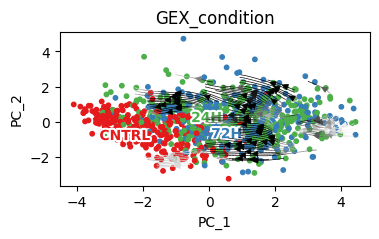

In [11]:
genes = ['PBX1','POU3F2','BACH2','CREB5']

color_dict_line = {
    'CNTRL': '#e41a1c', 
    '24H': '#4daf4a', 
    '72H': '#377eb8'}

from scenicplus.simulation import plot_perturbation_effect_in_embedding
import seaborn as sns
for i in genes: 
    _ = plot_perturbation_effect_in_embedding(
        scplus_obj = scplus_obj,
        reduction_name = 'eRegulons_PCA_gene_based',
        n_cpu = 5,
        perturbation = {str(i): 0}, #specifies that we want to set the expression of SOX10 to 0 in all cells.
        variable = 'GEX_condition',
        color_dictionary = {'GEX_condition': color_dict_line},
        genes_to_use = hvg,
        figsize = (4, 2),
        dot_size=10)
    _.figure.savefig('/wynton/home/pollenlab/jding/Sara/scenicplus/figures/'+ i + '.pdf')

2024-10-21 08:45:33,737 perturbation INFO     Caclulating perturbation matrix for: {'PBX1': 0} over 5 iterations.


100%|█████████████████████████████████████████| 500/500 [02:44<00:00,  3.04it/s]


2024-10-21 08:48:59,741 perturbation INFO     Generating ranking based on perturbed matrix.
2024-10-21 08:49:10,535 perturbation INFO     Scoring eRegulons.
2024-10-21 08:49:16,937 perturbation INFO     Projecting perturbation effect in embedding: eRegulons_PCA_gene_based
2024-10-21 08:49:17,370 perturbation INFO     Calculating grid of arrows
2024-10-21 08:49:17,460 perturbation INFO     Plotting


/wynton/home/pollenlab/jding/scenicplus/src/scenicplus/simulation.py:292: RuntimeWarning: invalid value encountered in divide
  unitary_vectors /= np.linalg.norm(unitary_vectors, ord=2, axis=0)  # divide by L2


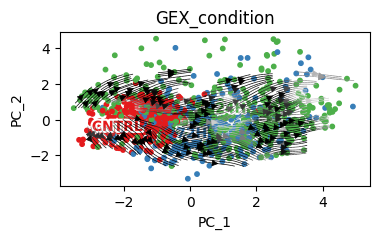

2024-10-21 08:49:22,493 perturbation INFO     Caclulating perturbation matrix for: {'POU3F2': 0} over 5 iterations.


100%|█████████████████████████████████████████| 500/500 [02:34<00:00,  3.24it/s]


2024-10-21 08:52:25,651 perturbation INFO     Generating ranking based on perturbed matrix.
2024-10-21 08:52:36,094 perturbation INFO     Scoring eRegulons.
2024-10-21 08:52:42,570 perturbation INFO     Projecting perturbation effect in embedding: eRegulons_PCA_gene_based
2024-10-21 08:52:43,055 perturbation INFO     Calculating grid of arrows
2024-10-21 08:52:43,137 perturbation INFO     Plotting


/wynton/home/pollenlab/jding/scenicplus/src/scenicplus/simulation.py:292: RuntimeWarning: invalid value encountered in divide
  unitary_vectors /= np.linalg.norm(unitary_vectors, ord=2, axis=0)  # divide by L2


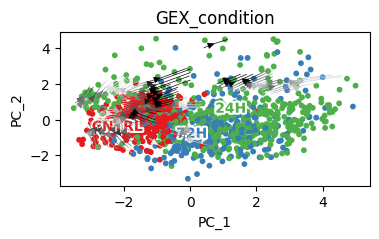

2024-10-21 08:52:48,199 perturbation INFO     Caclulating perturbation matrix for: {'BACH2': 0} over 5 iterations.


100%|█████████████████████████████████████████| 500/500 [02:32<00:00,  3.27it/s]


2024-10-21 08:55:44,678 perturbation INFO     Generating ranking based on perturbed matrix.
2024-10-21 08:55:55,259 perturbation INFO     Scoring eRegulons.
2024-10-21 08:56:01,791 perturbation INFO     Projecting perturbation effect in embedding: eRegulons_PCA_gene_based
2024-10-21 08:56:02,261 perturbation INFO     Calculating grid of arrows
2024-10-21 08:56:02,354 perturbation INFO     Plotting


/wynton/home/pollenlab/jding/scenicplus/src/scenicplus/simulation.py:292: RuntimeWarning: invalid value encountered in divide
  unitary_vectors /= np.linalg.norm(unitary_vectors, ord=2, axis=0)  # divide by L2


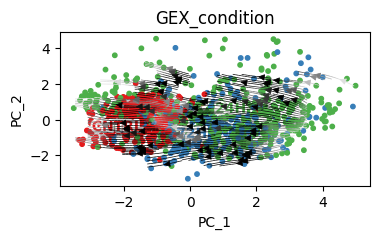

2024-10-21 08:56:07,395 perturbation INFO     Caclulating perturbation matrix for: {'CREB5': 0} over 5 iterations.


100%|█████████████████████████████████████████| 500/500 [02:48<00:00,  2.96it/s]


2024-10-21 08:59:06,405 perturbation INFO     Generating ranking based on perturbed matrix.
2024-10-21 08:59:17,000 perturbation INFO     Scoring eRegulons.
2024-10-21 08:59:23,262 perturbation INFO     Projecting perturbation effect in embedding: eRegulons_PCA_gene_based
2024-10-21 08:59:23,768 perturbation INFO     Calculating grid of arrows
2024-10-21 08:59:23,852 perturbation INFO     Plotting


/wynton/home/pollenlab/jding/scenicplus/src/scenicplus/simulation.py:292: RuntimeWarning: invalid value encountered in divide
  unitary_vectors /= np.linalg.norm(unitary_vectors, ord=2, axis=0)  # divide by L2


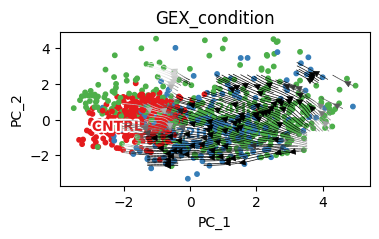

In [20]:
genes = ['PBX1','POU3F2','BACH2','CREB5']

color_dict_line = {
    'CNTRL': '#e41a1c', 
    '24H': '#4daf4a', 
    '72H': '#377eb8'}

from scenicplus.simulation import plot_perturbation_effect_in_embedding
import seaborn as sns
for i in genes: 
    _ = plot_perturbation_effect_in_embedding(
        scplus_obj = scplus_obj,
        reduction_name = 'eRegulons_PCA_gene_based',
        n_cpu = 5,
        perturbation = {str(i): 0}, #specifies that we want to set the expression of SOX10 to 0 in all cells.
        variable = 'GEX_condition',
        color_dictionary = {'GEX_condition': color_dict_line},
        genes_to_use = hvg,
        figsize = (4, 2),
        dot_size=10)
    _.figure.savefig('/wynton/home/pollenlab/jding/Sara/scenicplus/figures/chimp-'+ i + '.pdf')

2024-10-24 07:41:10,911 perturbation INFO     Caclulating perturbation matrix for: {'PBX1': 0} over 5 iterations.


100%|█████████████████████████████████████████| 500/500 [02:41<00:00,  3.10it/s]


2024-10-24 07:44:42,431 perturbation INFO     Generating ranking based on perturbed matrix.
2024-10-24 07:44:53,262 perturbation INFO     Scoring eRegulons.
2024-10-24 07:45:00,082 perturbation INFO     Projecting perturbation effect in embedding: eRegulons_PCA_gene_based
2024-10-24 07:45:00,596 perturbation INFO     Calculating grid of arrows
2024-10-24 07:45:00,676 perturbation INFO     Plotting


/wynton/home/pollenlab/jding/scenicplus/src/scenicplus/simulation.py:292: RuntimeWarning: invalid value encountered in divide
  unitary_vectors /= np.linalg.norm(unitary_vectors, ord=2, axis=0)  # divide by L2


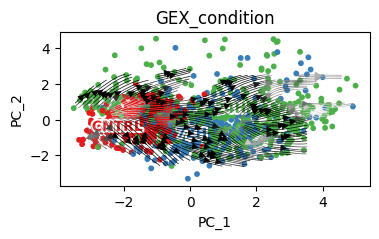

2024-10-24 07:45:05,462 perturbation INFO     Caclulating perturbation matrix for: {'POU3F2': 0} over 5 iterations.


100%|█████████████████████████████████████████| 500/500 [02:45<00:00,  3.03it/s]


2024-10-24 07:48:23,228 perturbation INFO     Generating ranking based on perturbed matrix.
2024-10-24 07:48:34,652 perturbation INFO     Scoring eRegulons.
2024-10-24 07:48:41,682 perturbation INFO     Projecting perturbation effect in embedding: eRegulons_PCA_gene_based
2024-10-24 07:48:42,176 perturbation INFO     Calculating grid of arrows
2024-10-24 07:48:42,269 perturbation INFO     Plotting


/wynton/home/pollenlab/jding/scenicplus/src/scenicplus/simulation.py:292: RuntimeWarning: invalid value encountered in divide
  unitary_vectors /= np.linalg.norm(unitary_vectors, ord=2, axis=0)  # divide by L2


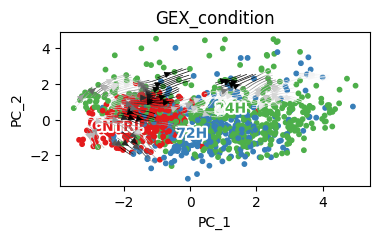

2024-10-24 07:48:47,158 perturbation INFO     Caclulating perturbation matrix for: {'BACH2': 0} over 5 iterations.


100%|█████████████████████████████████████████| 500/500 [02:38<00:00,  3.16it/s]


2024-10-24 07:51:57,799 perturbation INFO     Generating ranking based on perturbed matrix.
2024-10-24 07:52:08,680 perturbation INFO     Scoring eRegulons.
2024-10-24 07:52:15,674 perturbation INFO     Projecting perturbation effect in embedding: eRegulons_PCA_gene_based
2024-10-24 07:52:16,173 perturbation INFO     Calculating grid of arrows
2024-10-24 07:52:16,261 perturbation INFO     Plotting


/wynton/home/pollenlab/jding/scenicplus/src/scenicplus/simulation.py:292: RuntimeWarning: invalid value encountered in divide
  unitary_vectors /= np.linalg.norm(unitary_vectors, ord=2, axis=0)  # divide by L2


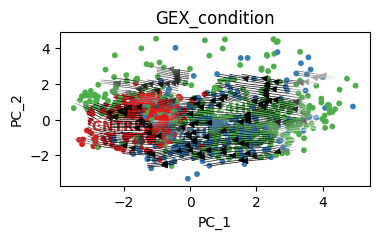

2024-10-24 07:52:20,886 perturbation INFO     Caclulating perturbation matrix for: {'CREB5': 0} over 5 iterations.


100%|█████████████████████████████████████████| 500/500 [02:46<00:00,  3.01it/s]


2024-10-24 07:55:19,434 perturbation INFO     Generating ranking based on perturbed matrix.
2024-10-24 07:55:29,965 perturbation INFO     Scoring eRegulons.
2024-10-24 07:55:36,860 perturbation INFO     Projecting perturbation effect in embedding: eRegulons_PCA_gene_based
2024-10-24 07:55:37,277 perturbation INFO     Calculating grid of arrows
2024-10-24 07:55:37,362 perturbation INFO     Plotting


/wynton/home/pollenlab/jding/scenicplus/src/scenicplus/simulation.py:292: RuntimeWarning: invalid value encountered in divide
  unitary_vectors /= np.linalg.norm(unitary_vectors, ord=2, axis=0)  # divide by L2


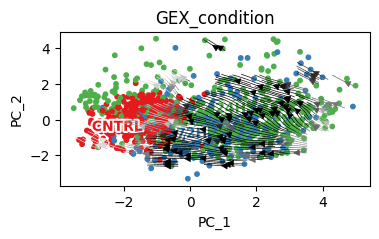

In [21]:
genes = ['PBX1','POU3F2','BACH2','CREB5']

color_dict_line = {
    'CNTRL': '#e41a1c', 
    '24H': '#4daf4a', 
    '72H': '#377eb8'}

from scenicplus.simulation import plot_perturbation_effect_in_embedding
import seaborn as sns
for i in genes: 
    _ = plot_perturbation_effect_in_embedding(
        scplus_obj = scplus_obj,
        reduction_name = 'eRegulons_PCA_gene_based',
        n_cpu = 5,
        perturbation = {str(i): 0}, #specifies that we want to set the expression of SOX10 to 0 in all cells.
        variable = 'GEX_condition',
        color_dictionary = {'GEX_condition': color_dict_line},
        genes_to_use = hvg,
        figsize = (4, 2),
        dot_size=10)
    _.figure.savefig('/wynton/home/pollenlab/jding/Sara/scenicplus/figures/chimp-'+ i + '.svg')

2024-10-24 08:04:50,487 perturbation INFO     Caclulating perturbation matrix for: {'PBX1': 0} over 5 iterations.


100%|█████████████████████████████████████████| 500/500 [02:30<00:00,  3.33it/s]


2024-10-24 08:07:32,978 perturbation INFO     Generating ranking based on perturbed matrix.
2024-10-24 08:07:37,462 perturbation INFO     Scoring eRegulons.
2024-10-24 08:07:42,984 perturbation INFO     Projecting perturbation effect in embedding: eRegulons_PCA_gene_based
2024-10-24 08:07:43,290 perturbation INFO     Calculating grid of arrows
2024-10-24 08:07:43,377 perturbation INFO     Plotting


/wynton/home/pollenlab/jding/scenicplus/src/scenicplus/simulation.py:292: RuntimeWarning: invalid value encountered in divide
  unitary_vectors /= np.linalg.norm(unitary_vectors, ord=2, axis=0)  # divide by L2


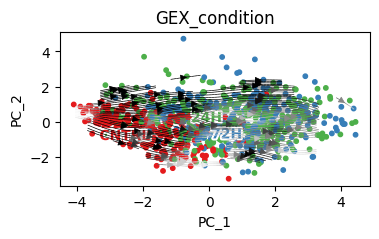

2024-10-24 08:07:47,985 perturbation INFO     Caclulating perturbation matrix for: {'POU3F2': 0} over 5 iterations.


100%|█████████████████████████████████████████| 500/500 [02:28<00:00,  3.36it/s]


2024-10-24 08:10:31,928 perturbation INFO     Generating ranking based on perturbed matrix.
2024-10-24 08:10:36,414 perturbation INFO     Scoring eRegulons.
2024-10-24 08:10:42,020 perturbation INFO     Projecting perturbation effect in embedding: eRegulons_PCA_gene_based
2024-10-24 08:10:42,314 perturbation INFO     Calculating grid of arrows
2024-10-24 08:10:42,399 perturbation INFO     Plotting


/wynton/home/pollenlab/jding/scenicplus/src/scenicplus/simulation.py:292: RuntimeWarning: invalid value encountered in divide
  unitary_vectors /= np.linalg.norm(unitary_vectors, ord=2, axis=0)  # divide by L2


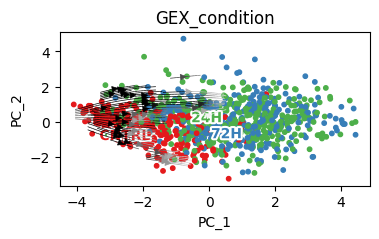

2024-10-24 08:10:46,757 perturbation INFO     Caclulating perturbation matrix for: {'BACH2': 0} over 5 iterations.


100%|█████████████████████████████████████████| 500/500 [02:29<00:00,  3.35it/s]


2024-10-24 08:13:32,111 perturbation INFO     Generating ranking based on perturbed matrix.
2024-10-24 08:13:36,662 perturbation INFO     Scoring eRegulons.
2024-10-24 08:13:42,256 perturbation INFO     Projecting perturbation effect in embedding: eRegulons_PCA_gene_based
2024-10-24 08:13:42,554 perturbation INFO     Calculating grid of arrows
2024-10-24 08:13:42,637 perturbation INFO     Plotting


/wynton/home/pollenlab/jding/scenicplus/src/scenicplus/simulation.py:292: RuntimeWarning: invalid value encountered in divide
  unitary_vectors /= np.linalg.norm(unitary_vectors, ord=2, axis=0)  # divide by L2


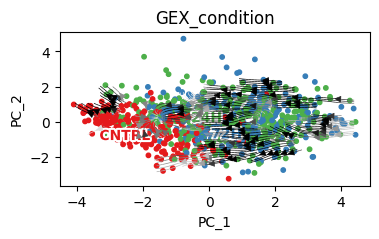

2024-10-24 08:13:47,100 perturbation INFO     Caclulating perturbation matrix for: {'CREB5': 0} over 5 iterations.


100%|█████████████████████████████████████████| 500/500 [02:30<00:00,  3.31it/s]


2024-10-24 08:16:24,421 perturbation INFO     Generating ranking based on perturbed matrix.
2024-10-24 08:16:29,151 perturbation INFO     Scoring eRegulons.
2024-10-24 08:16:34,470 perturbation INFO     Projecting perturbation effect in embedding: eRegulons_PCA_gene_based
2024-10-24 08:16:34,777 perturbation INFO     Calculating grid of arrows
2024-10-24 08:16:34,866 perturbation INFO     Plotting


/wynton/home/pollenlab/jding/scenicplus/src/scenicplus/simulation.py:292: RuntimeWarning: invalid value encountered in divide
  unitary_vectors /= np.linalg.norm(unitary_vectors, ord=2, axis=0)  # divide by L2


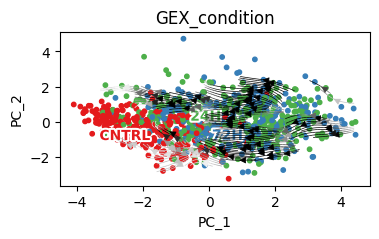

In [29]:
genes = ['PBX1','POU3F2','BACH2','CREB5']

color_dict_line = {
    'CNTRL': '#e41a1c', 
    '24H': '#4daf4a', 
    '72H': '#377eb8'}

from scenicplus.simulation import plot_perturbation_effect_in_embedding
import seaborn as sns
for i in genes: 
    _ = plot_perturbation_effect_in_embedding(
        scplus_obj = scplus_obj,
        reduction_name = 'eRegulons_PCA_gene_based',
        n_cpu = 5,
        perturbation = {str(i): 0}, #specifies that we want to set the expression of SOX10 to 0 in all cells.
        variable = 'GEX_condition',
        color_dictionary = {'GEX_condition': color_dict_line},
        genes_to_use = hvg,
        figsize = (4, 2),
        dot_size=10)
    _.figure.savefig('/wynton/home/pollenlab/jding/Sara/scenicplus/figures/human-'+ i + '.svg')